# 02b — The model comparison: five approaches across four horizons

**ARICast — forecasting acute respiratory illness (ARI) ED visit load.**

The headline comparison, on identical rolling cross-validation windows (`initial=900,
step=30`) for each geography. Five approaches:

| Approach | What it is |
|---|---|
| **Persistence** | $\hat{y}_t = y_{c-1}$ — repeat the last observed value. Pure inertia. |
| **Seasonal-naive** | $\hat{y}_t = y_{t-365}$ — the value one year earlier. Pure seasonality. |
| **Prophet (two-regime)** | Additive Prophet; trend flexibility chosen by *regime*: flexible (`cps=0.5`) for short horizons, stiff (`cps≈0.001–0.01`) for long. US holidays. |
| **ARIMA + Fourier** | `auto_arima` (order per window) with Fourier yearly+weekly terms. |

**Headline finding:** *the right model depends on the forecast horizon* — and so do the
baselines. At 7 days ARIMA+Fourier wins and **persistence** is a remarkably strong runner-up;
by 90 days every complex model degrades to (or below) a **seasonal-naive** baseline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})

M = pd.read_csv("../data/processed/master_comparison.csv").sort_values(["series","horizon"])
FIGS = Path("../reports/figures"); FIGS.mkdir(parents=True, exist_ok=True)
M[["series","horizon","persistence_MAPE","naive_MAPE","prophet_MAPE","arima_MAPE"]]

,series,horizon,persistence_MAPE,naive_MAPE,prophet_MAPE,arima_MAPE
0,California,7,4.64,9.36,9.12,3.51
1,California,14,5.70,9.83,11.04,5.14
2,California,30,9.58,10.25,11.77,8.53
3,California,90,18.87,10.44,13.70,15.08
4,United States,7,5.03,10.76,4.53,3.29
5,United States,14,6.95,11.04,5.60,5.12
6,United States,30,10.76,11.50,8.20,7.63
7,United States,90,21.83,12.14,8.82,12.07


## 1. The two baselines are not interchangeable

ARICast uses **two** trivial baselines because they capture opposite intuitions, and each
dominates at a different horizon:

- **Persistence** ("tomorrow ≈ today") is excellent *short*: at 7 days it scores 5.0% (US) /
  4.6% (CA) — far better than seasonal-naive, and within striking distance of ARIMA. It
  collapses *long* (21.8% / 18.9% at 90 days), because today's value says nothing about a day
  three months out.
- **Seasonal-naive** ("this day ≈ same day last year") is mediocre short but *horizon-robust*:
  ~10–12% at every horizon, so it actually **wins outright at 90 days**.

A model only earns its complexity if it beats *whichever* baseline is strong at that horizon.

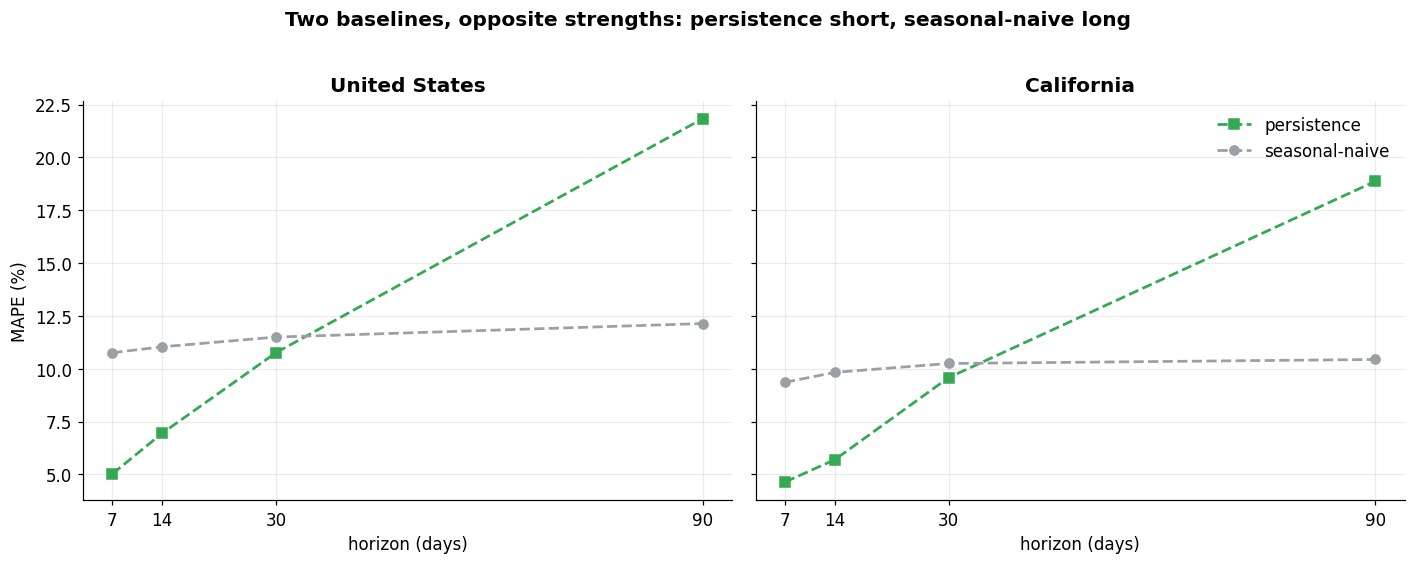

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, geo in zip(axes, ["United States", "California"]):
    d = M[M.series == geo].sort_values("horizon")
    ax.plot(d.horizon, d.persistence_MAPE, "s--", color="#34a853", label="persistence", lw=1.8)
    ax.plot(d.horizon, d.naive_MAPE, "o--", color="#9aa0a6", label="seasonal-naive", lw=1.8)
    ax.set_title(geo, fontweight="bold"); ax.set_xlabel("horizon (days)"); ax.set_xticks(d.horizon)
axes[0].set_ylabel("MAPE (%)"); axes[1].legend(frameon=False)
fig.suptitle("Two baselines, opposite strengths: persistence short, seasonal-naive long",
             fontweight="bold", y=1.02)
fig.tight_layout(); fig.savefig(FIGS / "02b_baselines.png", dpi=130, bbox_inches="tight"); plt.show()

## 2. Full comparison table

In [3]:
def fmt(m): return f"{m:.2f}"
tbl = M.assign(
    Persistence=M.persistence_MAPE.map(fmt),
    **{"Seasonal-naive": M.naive_MAPE.map(fmt),
       "Prophet": M.prophet_MAPE.map(fmt),
       "ARIMA+Fourier": M.arima_MAPE.map(fmt)}
)[["horizon","series","Persistence","Seasonal-naive","Prophet","ARIMA+Fourier"]]
tbl.columns = ["Horizon (d)","Series","Persistence","Seasonal-naive","Prophet","ARIMA+Fourier"]
tbl

,Horizon (d),Series,Persistence,Seasonal-naive,Prophet,ARIMA+Fourier
0,7,California,4.64,9.36,9.12,3.51
1,14,California,5.70,9.83,11.04,5.14
2,30,California,9.58,10.25,11.77,8.53
3,90,California,18.87,10.44,13.70,15.08
4,7,United States,5.03,10.76,4.53,3.29
5,14,United States,6.95,11.04,5.60,5.12
6,30,United States,10.76,11.50,8.20,7.63
7,90,United States,21.83,12.14,8.82,12.07


In [4]:
def winner(r):
    v = {"persistence": r.persistence_MAPE, "seasonal-naive": r.naive_MAPE,
         "Prophet": r.prophet_MAPE, "ARIMA": r.arima_MAPE}
    return min(v, key=v.get)
M2 = M.copy(); M2["winner"] = M2.apply(winner, axis=1)
print("Best approach by horizon x series:")
print(M2.pivot(index="horizon", columns="series", values="winner").to_string())

Best approach by horizon x series:
series       California United States
horizon                              
7                 ARIMA         ARIMA
14                ARIMA         ARIMA
30                ARIMA         ARIMA
90       seasonal-naive       Prophet


## 3. MAPE vs horizon — all five lines

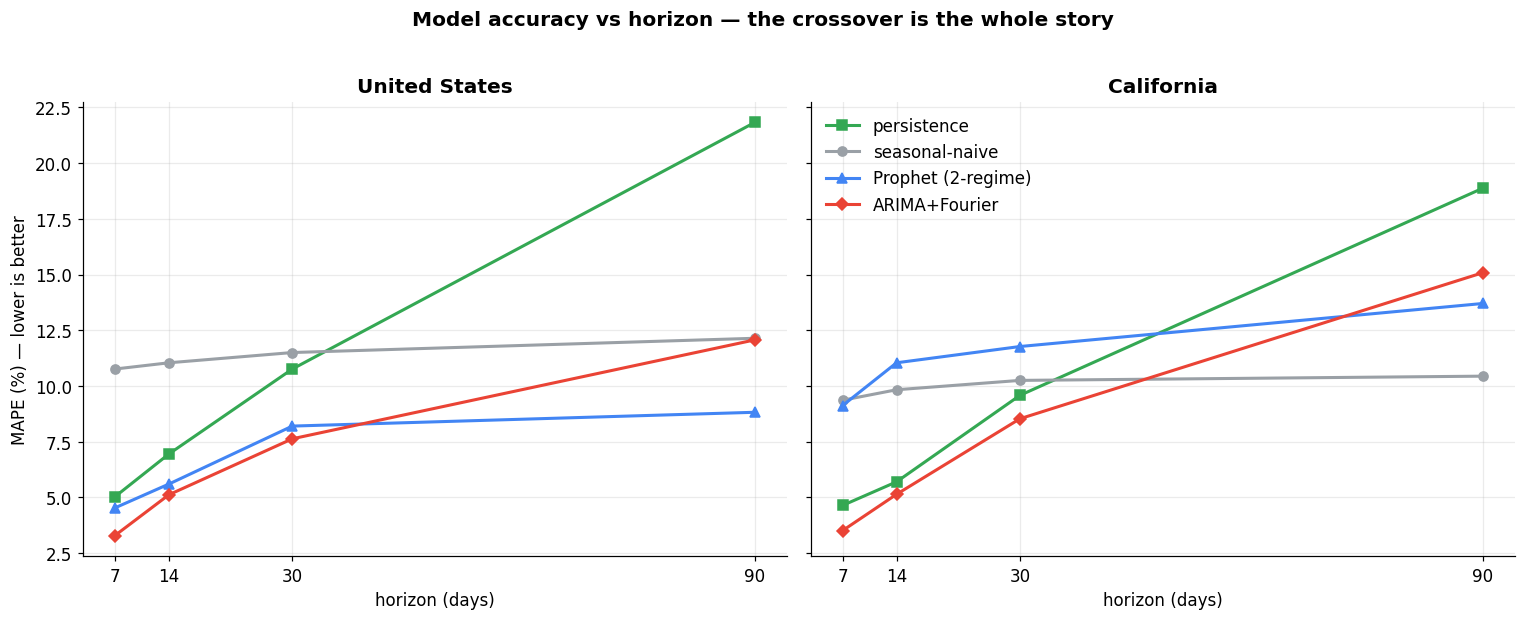

In [5]:
colors = {"persistence":"#34a853","naive":"#9aa0a6","prophet":"#4285f4","arima":"#ea4335"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, geo in zip(axes, ["United States", "California"]):
    d = M[M.series == geo].sort_values("horizon")
    ax.plot(d.horizon, d.persistence_MAPE, "s-", color=colors["persistence"], label="persistence", lw=2)
    ax.plot(d.horizon, d.naive_MAPE, "o-", color=colors["naive"], label="seasonal-naive", lw=2)
    ax.plot(d.horizon, d.prophet_MAPE, "^-", color=colors["prophet"], label="Prophet (2-regime)", lw=2)
    ax.plot(d.horizon, d.arima_MAPE, "D-", color=colors["arima"], label="ARIMA+Fourier", lw=2)
    ax.set_title(geo, fontweight="bold"); ax.set_xlabel("horizon (days)"); ax.set_xticks(d.horizon)
axes[0].set_ylabel("MAPE (%) — lower is better"); axes[1].legend(frameon=False, loc="upper left")
fig.suptitle("Model accuracy vs horizon — the crossover is the whole story",
             fontweight="bold", y=1.02)
fig.tight_layout(); fig.savefig(FIGS / "02b_mape_vs_horizon.png", dpi=130, bbox_inches="tight"); plt.show()

## 4. Reading the crossover

- **7 days (operational).** ARIMA+Fourier wins on both series (US 3.29%, CA 3.51%). The
  surprise is **persistence**: at 5.0% / 4.6% it beats Prophet on CA and trails ARIMA only
  slightly — a "do-nothing" forecast is the second-best model at the horizon that matters.
- **14 days.** ARIMA still leads; Prophet competitive on US.
- **30 days.** ARIMA and Prophet converge; the complex models lose their clear edge.
- **90 days.** Everything degrades. US is won by **Prophet** (8.8%, stiff-trend regime), CA by
  **seasonal-naive** (10.4%). ARIMA and persistence are the *worst* options here.

The practical rule that falls out: **use ARIMA+Fourier for 0–14 day operational planning; fall
back to seasonal-naive (or stiff Prophet on US) for a 90-day seasonal orientation.** Anything
fancier than the right baseline at 90 days is wasted complexity.

## 5. Why these numbers are trustworthy — three guardrails

This project earned its numbers by repeatedly catching itself being fooled:

1. **Single-split traps (×3).** A single train/test split gave Prophet-CA 6.8% (CV: 11.0%),
   ARIMA-US-90d 4.77% (CV: 18.7%), and Prophet-US 9.3% from built-in CV vs 16.9% from manual
   rolling CV. Fix: every model scored on identical rolling windows, mean ± std.
2. **Horizon/window mismatch.** An early table compared seasonal-naive on a 365-day holdout
   against Prophet on a 90-day CV — apples to oranges. Fix: identical windows *and* horizon.
3. **Hyperparameter overfitting (Phase 2c).** Tuning Prophet's `cps` on the same windows used
   to report inflates the score by up to ~4.5 points (the *optimism gap*). Fix: Prophet uses a
   tiny, theory-motivated **two-regime** trend setting (flexible short, stiff long) rather than
   a per-window-tuned optimum.

The std columns carry information too: ARIMA's spread grows from ~2 pp at 7 days to ~5–11 pp at
90 days. Long-horizon models are not just worse on average — they are far less stable.

In [6]:
piv = M.pivot_table(index="horizon", columns="series", values="arima_std").round(2)
print("ARIMA+Fourier MAPE std (pp) by horizon — instability grows with horizon:")
print(piv.to_string())

ARIMA+Fourier MAPE std (pp) by horizon — instability grows with horizon:
series   California  United States
horizon                           
7              1.87           1.97
14             3.19           2.80
30             5.65           4.48
90            10.74           5.36


## 6. auto_arima order stability

In [7]:
from collections import Counter
import ast
for geo in ["United States", "California"]:
    raw = M[M.series == geo].iloc[0]["arima_orders"]
    orders = ast.literal_eval(raw)
    c = Counter(orders); total = sum(c.values())
    top, n = c.most_common(1)[0]
    print(f"{geo:14s}: most common order = {top} ({100*n/total:.0f}% of windows), "
          f"(2,1,2) share = {100*c.get((2,1,2),0)/total:.0f}%")

United States : most common order = (2, 1, 2) (47% of windows), (2,1,2) share = 47%
California    : most common order = (2, 1, 3) (60% of windows), (2,1,2) share = 0%


## 7. Conclusion

ARICast's deliverable is not "the best model" but **a horizon-aware recommendation backed by
honest validation**:

- **0–14 days:** ARIMA+Fourier (MAPE ~3–5%) — the operational tool for shift-level staffing.
- **~30 days:** ARIMA / Prophet parity.
- **90 days:** seasonal-naive (or stiff Prophet on US) — do not oversell complexity.

The project was renamed from *ProphetCast* to *ARICast* precisely because Prophet does not win
at the horizon that matters; naming the subject (ARI) instead of the tool keeps the story
honest. And the methodological spine — naive baselines first, identical CV windows, and a
measured optimism gap — is the part that makes the modeling defensible rather than merely
presentable.